# Work 2

## Imports

In [1]:
import pandas as pd
import os
from dotenv import load_dotenv
import pyarrow
from pathlib import Path
import boto3

In [2]:
load_dotenv()
os.getenv('AWS_ACCESS_KEY_ID') is not None

True

## Data set loading 

In [3]:
s3 = boto3.client('s3')

BUCKET = 'zrive-ds-data'
PREFIX = 'groceries/box_builder_dataset/'

response = s3.list_objects_v2(
    Bucket = BUCKET,
    Prefix = PREFIX
)

key = response['Contents'][0]['Key']
filename = response['Contents'][0]['Key'].split('/')[-1]

local_data_dir = Path('../../data/module2')
local_path = local_data_dir/filename

if local_path.exists():
        print(f'{filename} already exists')
else:
    print(f'Downloading: {filename}')
    s3.download_file(BUCKET,key,local_path)

feature_frame.csv already exists


In [4]:
df = pd.read_csv(local_path)
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


## EDA 1: Quick SAnity and integrity check

In [5]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values (%):\n", df.isna().mean()*100)
print("\nDuplicated rows:", df.duplicated().sum())

Shape: (2880549, 27)
Columns: ['variant_id', 'product_type', 'order_id', 'user_id', 'created_at', 'order_date', 'user_order_seq', 'outcome', 'ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular', 'normalised_price', 'discount_pct', 'vendor', 'global_popularity', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby', 'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 'days_since_purchase_product_type', 'avg_days_to_buy_product_type', 'std_days_to_buy_product_type']

Data types:
 variant_id                            int64
product_type                         object
order_id                              int64
user_id                               int64
created_at                           object
order_date                           object
user_order_seq                        int64
outcome                             float64
ordered_before                      float64
abandoned_before                

For now, the analysis shows that there is no columns with relatively strange percentages of na or duplicates. 
The datatypes are the ones expected for the columns except for created at and order date, which should be transformed into datetime. 
The shape fits the idea os a supermarket, a los of rows representign the pair (product,order) 
and several columns regarding the data.

In [6]:
date_cols = ['created_at','order_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col],errors = 'coerce')

df[date_cols].dtypes

created_at    datetime64[ns]
order_date    datetime64[ns]
dtype: object

## EDA 2: Data integrity

Each row represents an (order, product) pair, where the outcome variable indicates 
whether the product was purchased or not.

**Lets check the unique key**

In [7]:
df[['variant_id','order_id']].duplicated().sum()

0

In [8]:
df['outcome'].value_counts()

outcome
0.0    2847317
1.0      33232
Name: count, dtype: int64

No other values than 1 or 0, so that is correct.

In [9]:
df[['variant_id','order_id','outcome']].isna().sum()

variant_id    0
order_id      0
outcome       0
dtype: int64

The columnas that should always be filled, are indeed

## EDA 3: Univariant analysis

In [16]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns
date_cols = df.select_dtypes(include=["datetime64"]).columns

In [10]:
target_counts = df['outcome'].value_counts()
print(target_counts)

outcome
0.0    2847317
1.0      33232
Name: count, dtype: int64


In [11]:
target_ratio =  df['outcome'].value_counts(normalize = True)
print(target_ratio)

outcome
0.0    0.988463
1.0    0.011537
Name: proportion, dtype: float64


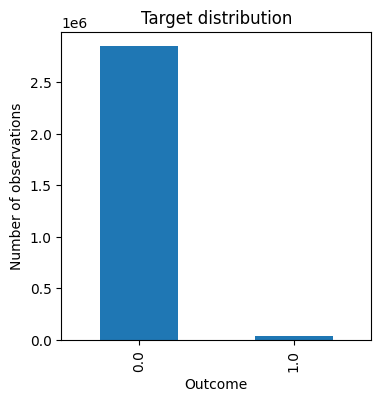

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
target_counts.plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Number of observations")
plt.title("Target distribution")
plt.show()

The target variable is imbalanced, with a higher proportion of non-purchased 
(product not bought) outcomes compared to purchased ones. This imbalance is 
expected in a supermarket context context and should be taken into account in downstream 
modeling and evaluation.

In [20]:
df.groupby("order_id")["outcome"].mean().describe()

count    3446.000000
mean        0.011713
std         0.008447
min         0.000000
25%         0.005663
50%         0.010518
75%         0.015964
max         0.089143
Name: outcome, dtype: float64

We can observe that from the products for each order, only 1.1% ends to be purchased.

In [19]:
df[num_cols].describe()

,variant_id,order_id,user_id,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
count,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,...,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06
mean,3.401250e+13,2.978388e+12,3.750025e+12,3.289342e+00,1.153669e-02,2.113868e-02,6.092589e-04,2.290188e-03,3.629864e-03,1.272808e-01,...,5.492182e-02,3.538562e-03,5.134091e-02,2.072549e+00,3.312961e+01,3.523734e+01,2.645304e+01,3.143513e+01,3.088810e+01,2.594969e+01
std,2.786246e+11,2.446292e+11,1.775710e+11,2.140176e+00,1.067876e-01,1.438466e-01,2.467565e-02,4.780109e-02,6.013891e-02,1.268378e-01,...,3.276586e-01,5.938048e-02,3.013646e-01,3.943659e-01,3.707162e+00,1.057766e+01,7.168323e+00,1.227511e+01,4.330262e+00,3.278860e+00
min,3.361529e+13,2.807986e+12,3.046041e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.599349e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.414214e+00,0.000000e+00,7.000000e+00,2.828427e+00
25%,3.380354e+13,2.875152e+12,3.745901e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.394416e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.000000e+01,2.319372e+01,3.000000e+01,2.800000e+01,2.427618e+01
50%,3.397325e+13,2.902856e+12,3.812775e+12,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.105178e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01,2.769305e+01,3.000000e+01,3.100000e+01,2.608188e+01
75%,3.428495e+13,2.922034e+12,3.874925e+12,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.352670e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,4.000000e+01,3.059484e+01,3.000000e+01,3.400000e+01,2.796118e+01
max,3.454300e+13,3.643302e+12,5.029635e+12,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,3.000000e+00,1.000000e+00,6.000000e+00,5.000000e+00,1.480000e+02,8.400000e+01,5.868986e+01,1.480000e+02,3.950000e+01,3.564191e+01


In [20]:
df['normalised_price'].describe()

count    2.880549e+06
mean     1.272808e-01
std      1.268378e-01
min      1.599349e-02
25%      5.394416e-02
50%      8.105178e-02
75%      1.352670e-01
max      1.000000e+00
Name: normalised_price, dtype: float64

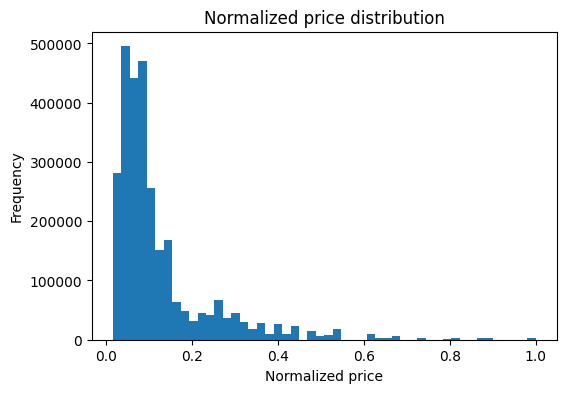

In [31]:
df["normalised_price"].plot(kind="hist", bins=50,figsize = (6,4), logy=False)
plt.xlabel("Normalized price")
plt.ylabel("Frequency")
plt.title("Normalized price distribution")
plt.show()

The normalized distribution shows a right-skewed curve, indicating that a high volume of products have a realtively low price, while a small subset of products have relatively higher prices. This matches the idea of a supermarket that may have a lot of affordable product, and a small quantity of luxury-ones.

In [29]:
df[cat_cols].describe()

,product_type,vendor
count,2880549,2880549
unique,62,264
top,tinspackagedfoods,biona
freq,226474,146828


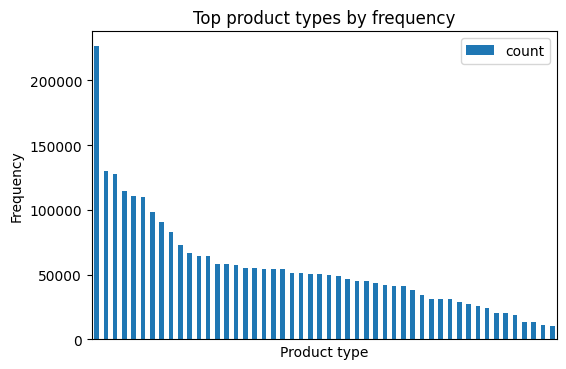

In [48]:
product_type_counts = df['product_type'].value_counts().reset_index()

product_type_counts.head(50).plot(
    kind = 'bar',
    figsize = (6,4)
)
plt.xlabel("Product type")
plt.xticks([])
plt.ylabel("Frequency")
plt.title("Top product types by frequency")
plt.show()

In [55]:
product_type_counts['percentage'] = product_type_counts['count']/len(df)*100
product_type_counts.head(10)

,product_type,count,percentage
0,tinspackagedfoods,226474,7.862182
1,condimentsdressings,129749,4.504315
2,ricepastapulses,128098,4.447000
3,haircare,114978,3.991531
4,cookingingredientsoils,110686,3.842531
5,longlifemilksubstitutes,110235,3.826875
6,dishwasherdetergent,98144,3.407128
7,cereal,90898,3.155579
8,bathroomlimescalecleaner,82632,2.868620
9,kidssnacks,72554,2.518756


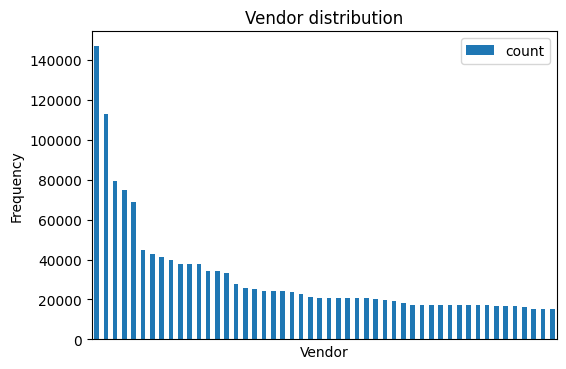

In [56]:
vendor_counts = df['vendor'].value_counts().reset_index()

vendor_counts.head(50).plot(
    kind = 'bar',
    figsize = (6,4)
)

plt.title('Vendor distribution')
plt.ylabel('Frequency')
plt.xlabel('Vendor')
plt.xticks([])
plt.show()

In [58]:
vendor_counts['percent'] = vendor_counts['count']/len(df)*100
vendor_counts.head(10)

,vendor,count,percent
0,biona,146828,5.097223
1,ecover,113018,3.923488
2,method,79258,2.751489
3,organix,74632,2.590895
4,treeoflife,68920,2.392599
5,huggies,44765,1.554044
6,bulldog,42739,1.483710
7,clearspring,41352,1.435560
8,cooksco,39960,1.387236
9,biod,37906,1.315930


## EDA 4: Bivariant analysis

### Price vs outcome

In [60]:
df.groupby('outcome')['normalised_price'].describe()

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
0.0,2847317.0,0.127548,0.127160,0.015993,0.053944,0.081052,0.135267,1.00000
1.0,33232.0,0.104372,0.092433,0.015993,0.051233,0.078341,0.113581,0.89428


<Figure size 600x400 with 0 Axes>

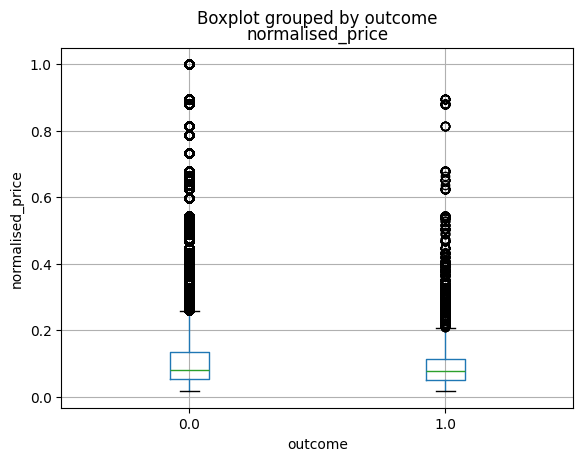

In [63]:
plt.figure(figsize = (6,4))
df.boxplot(
    column = 'normalised_price',
    by = 'outcome'
)
plt.xlabel('outcome')
plt.ylabel('normalised_price')
plt.show()

Price by its own seems not to have a strong relation to the outcome of the order

### Product type vs outcome

,product_type,outcome
0,toiletroll,0.062475
1,binbags,0.040990
2,kitchenrolltissues,0.034691
3,snacksconfectionery,0.026277
4,homebaking,0.020012
5,washingcapsules,0.019795
6,tinspackagedfoods,0.019645
7,softdrinksmixers,0.017696
8,cereal,0.016755
9,longlifemilksubstitutes,0.016429


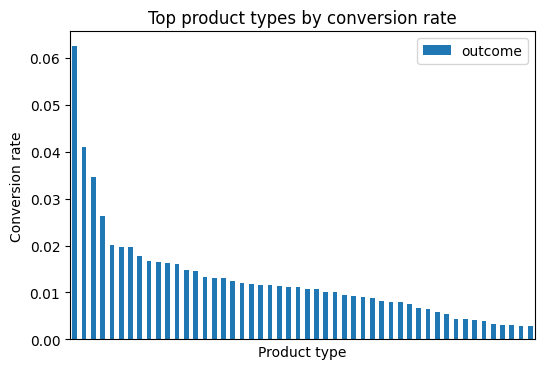

In [76]:
type_conversion_rate = df.groupby('product_type')['outcome'].mean().sort_values(ascending = False)
type_conversion_rate.reset_index().head(50).plot(kind='bar',figsize = (6,4))
plt.xlabel('Product type')
plt.ylabel('Conversion rate')
plt.title('Top product types by conversion rate')
plt.xticks([])

type_conversion_rate.reset_index().head(10)


In the analysis we can see that the product type has direct relation with the outcome or the product, some of the product type have a realtively higer conversion rate than other, althoug is a very small group.

### Vendor vs outcome

,vendor,outcome
0,whogivesacrap,0.086761
1,oatly,0.070081
2,plenty,0.064099
3,andrex,0.051509
4,taylorsofharrogate,0.048462
5,tonyschocolonely,0.046359
6,ritz,0.044689
7,thecheekypanda,0.042948
8,symphony,0.042948
9,weetabix,0.042368


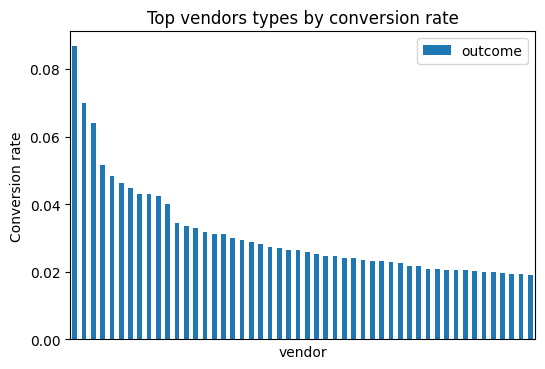

In [79]:
vendor_conversion_rate = df.groupby('vendor')['outcome'].mean().sort_values(ascending = False)
vendor_conversion_rate.reset_index().head(50).plot(kind='bar',figsize = (6,4))
plt.xlabel('vendor')
plt.ylabel('Conversion rate')
plt.title('Top vendors types by conversion rate')
plt.xticks([])

vendor_conversion_rate.reset_index().head(10)

Again, a clear difference in conversion rate between vendors is seen in the graph. This provides useful information in predicting the outcome, suggesting strong 
categorical effect

### Abandoned before vs outcome

In [86]:
abandoned_counts = df.groupby('abandoned_before')['outcome'].value_counts().reset_index()
abandoned_counts.head()


,abandoned_before,outcome,count
0,0.0,0.0,2846822
1,0.0,1.0,31972
2,1.0,1.0,1260
3,1.0,0.0,495


In [94]:
conversion_rate = df.groupby("abandoned_before")["outcome"].mean().reset_index().rename(columns={"outcome":'conversion_rate'})
conversion_rate.head()

,abandoned_before,conversion_rate
0,0.0,0.011106
1,1.0,0.717949


- The feature `abandoned_before` shows a very strong association with the outcome, 
with a conversion rate above 70%. However, this effect should be interpreted with 
caution, as the group of observations where `abandoned_before = 1` represents a 
very small fraction of the dataset. This suggests that the feature captures a very 
specific user–product interaction and may encode strong temporal or behavioral signals.

- We ahould ask to the business what does this feature represent, as doesn´t seem to be only that the user had previously abandoned any cart. It would make sense to be that the user had previously abandoned the same cart, so that when he/she returns to it, it has a very high conversion rate.

### Set as regular vs outcome

In [104]:
set_as_regular_counts = df['set_as_regular'].value_counts().reset_index()
set_as_regular_counts['conversion_rate'] = df.groupby('set_as_regular')['outcome'].mean()
set_as_regular_counts.head()


,set_as_regular,count,conversion_rate
0,0.0,2870093,0.010669
1,1.0,10456,0.249713


### Ordered before vs outcome


In [108]:
ordered_before_counts = df['ordered_before'].value_counts().reset_index()
ordered_before_counts['conversion_rate'] = df.groupby('ordered_before')['outcome'].mean()
ordered_before_counts.head()

,ordered_before,count,conversion_rate
0,0.0,2819658,0.008223
1,1.0,60891,0.164967


### Key insights from exploratory analysis

- The dataset is highly imbalanced, with only a small fraction of product–order 
  pairs resulting in a purchase.
- Normalized price alone does not strongly discriminate purchase outcomes.
- Product type and vendor show substantial differences in conversion rates.
- The feature `abandoned_before` is highly predictive but affects a very small 
  subset of observations and may have another meaning that the one supposed.
- The set_as_regular feature appears to be highly predictive, with almos a difference of 25% in conversion rate.
- The ordered_before feature appears to be highly predictive, with almost a difference of 16% in conversion rate.

## Final Insights of the EDA


Regarding univariate and bivariate analysis, the target variable (`outcome`) is 
highly imbalanced, with only a small fraction of product–order pairs resulting in 
a purchase.

A total of six features were analyzed in relation to the target variable. The main 
findings are summarized below:

- Normalized price does not show strong discriminative power when analyzed in 
  isolation.
- Vendor and product type exhibit heterogeneous conversion rates, with a small 
  subset of categories achieving relatively high conversion. However, these features 
  alone do not provide sufficient separation across all classes and may require 
  combination with other signals.
- The features `set_as_regular` and `ordered_before` show strong associations with 
  the target variable, with differences in conversion rates of approximately 20% 
  and 16%, respectively.
- The feature `abandoned_before` exhibits a very strong association with the target. 
  However, its behavior appears counterintuitive under the assumption that it 
  represents prior abandonment of the same product. This suggests that the feature 
  may encode a different behavioral signal and should be further 
  clarified and reinterpreted before being used as a predictive feature.